# M1 CafeF Market Foundation — Inspection Notebook

**Purpose:** inspect the immutable `m1-market-foundation-v1` report artifact.

**Source of truth:** report artifact files, not this notebook.

> M1 MARKET DATA FOUNDATION: **COMPLETE FOR MARKET-ONLY EXPERIMENT PREPARATION**
> Strict research gate: **NOT READY**. Market feature readiness, tradability,
> historical identity readiness and research readiness are distinct gates.


In [10]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

REPORT_DIR = Path("artifacts/reports/m1-market-foundation-v1")
if not REPORT_DIR.is_dir():
    for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = parent / "artifacts/reports/m1-market-foundation-v1"
        if candidate.is_dir():
            REPORT_DIR = candidate
            break
if not REPORT_DIR.is_dir():
    raise FileNotFoundError(f"Explicit report artifact is missing: {REPORT_DIR.resolve()}")
print(f"Report directory: {REPORT_DIR.resolve()}")


Report directory: C:\Projects\Intern\SourceCode-CafeF\artifacts\reports\m1-market-foundation-v1


In [11]:
report = json.loads((REPORT_DIR / "report.json").read_text(encoding="utf-8"))
print("Artifact:", report["artifact_id"])
print("Stage:", report["stage"])
print("Snapshot:", report["snapshot_date"])
print("Integrity:", report["integrity"]["status"])
print("Network requests:", report["network_requests"])


Artifact: m1-market-foundation-v1
Stage: M1-REPORT
Snapshot: 2026-08-28
Integrity: PASS
Network requests: 0


## Integrity and provenance

The generator verifies the parent C8, C8-VERIFY and R1 manifests before writing
this report. C8 is not rerun.


In [12]:
pd.Series(report["parent_manifests"], name="sha256").to_frame()


,sha256
parent_c8_manifest_sha256,01ed9e890103c894239ac30accc781260de547b73193ec...
parent_c8_verify_manifest_sha256,0ff737d204a04919a79b606351e4dbf69a3e7145c2eade...
r1_manifest_sha256,b8875c0686dc48b0581a9f64f445948b831d4f3c4732b4...


## M1 readiness summary

Market-only experiment preparation may proceed under an explicit protocol.
This does not authorize research-ready promotion, a backtest, investment claims,
or a final research-universe claim.


In [13]:
headline = pd.Series(report["headline"], name="count").to_frame()
display(headline)
print("Market ready != tradability != historical identity ready != research ready")


,count
baseline_count,500
candidate_count,952
complete_expansion_count,452
deferred_expansion_count,148
feature_complete,922
historical_identity_ready,0
latest253_complete,922
latest253_incomplete,30
market_feature_ready_v2,905
market_readiness_failures,47


Market ready != tradability != historical identity ready != research ready


## Required feature coverage

In [14]:
feature_coverage = pd.read_csv(REPORT_DIR / "feature_coverage.csv")
display(feature_coverage)


,feature,available,missing,available_percentage,denominator,snapshot_date
0,mom_21,949,3,99.684874,952,2026-08-28
1,mom_63,946,6,99.369748,952,2026-08-28
2,mom_126,938,14,98.529412,952,2026-08-28
3,mom_252,922,30,96.848739,952,2026-08-28
4,vol_63,946,6,99.369748,952,2026-08-28
5,mdd_126,938,14,98.529412,952,2026-08-28
6,beta_126,938,14,98.529412,952,2026-08-28
7,liquidity_21,949,3,99.684874,952,2026-08-28


## Source and exchange composition

In [15]:
by_source = pd.read_csv(REPORT_DIR / "composition_by_source.csv")
by_exchange = pd.read_csv(REPORT_DIR / "composition_by_exchange.csv")
display(by_source)
display(by_exchange)
print("Descriptive composition only; neither cohort is claimed statistically representative.")


,candidate_source,candidate_count,feature_complete,market_ready,latest253_complete,latest253_incomplete,ACTIVE,OBSERVED_ZERO_VOLUME,UNKNOWN,market_readiness_rate
0,C5_BASELINE_500,500,490,490,490,10,381,119,0,98.000000
1,C7_COMPLETE_EXPANSION,452,432,415,432,20,294,157,1,91.814159


,exchange,candidate_count,feature_complete,market_ready,market_not_ready,market_readiness_rate
0,HNX,249,249,248,1,99.598394
1,HOSE,319,304,297,22,93.103448
2,UPCOM,384,369,360,24,93.750000


Descriptive composition only; neither cohort is claimed statistically representative.


## Pre-generated deterministic charts

universe_composition.png


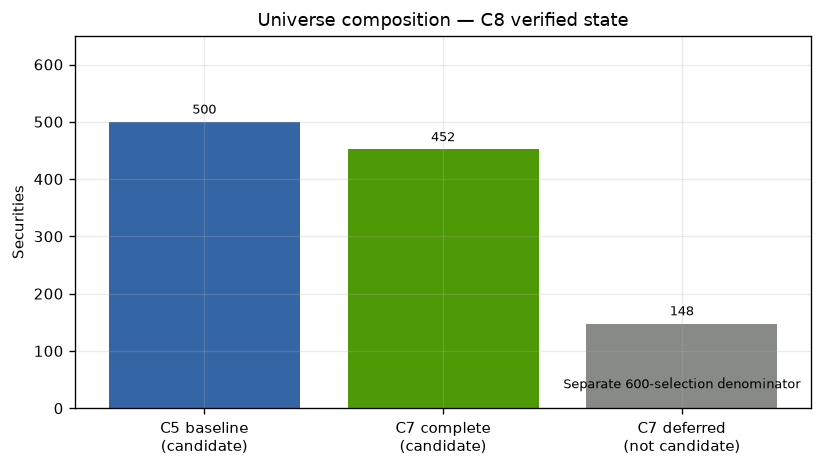

readiness_funnel.png


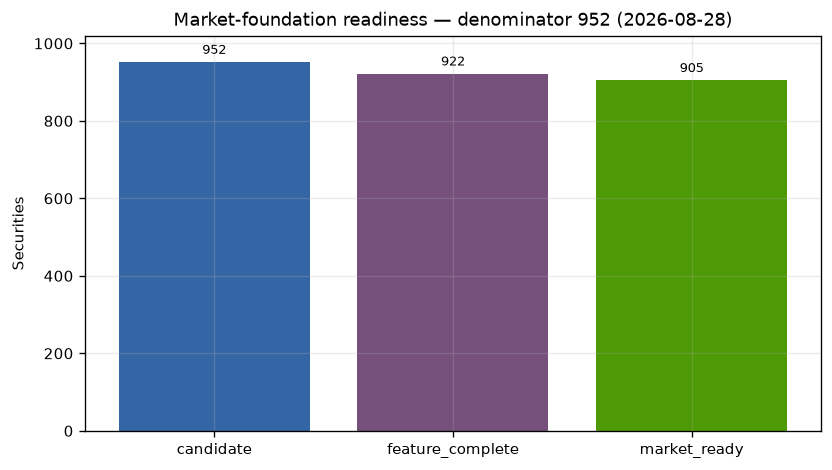

required_feature_coverage.png


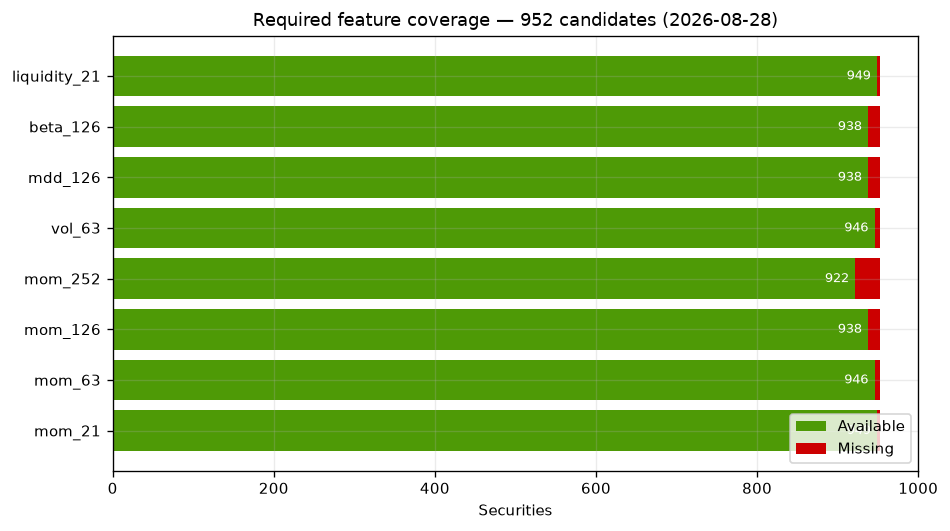

latest253_status.png


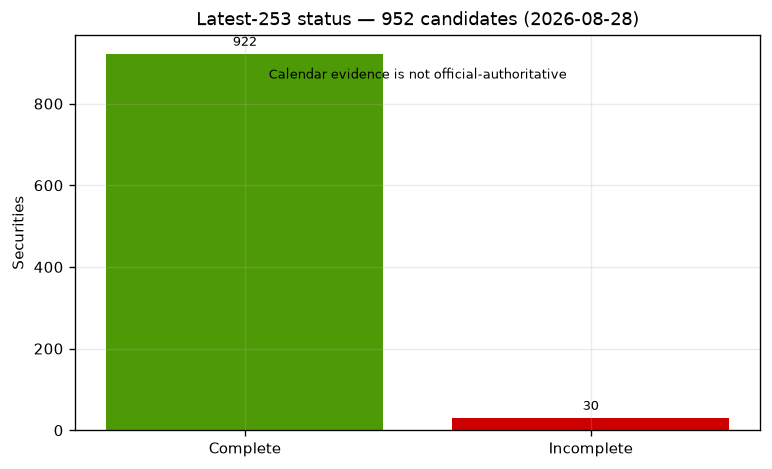

market_readiness_blockers.png


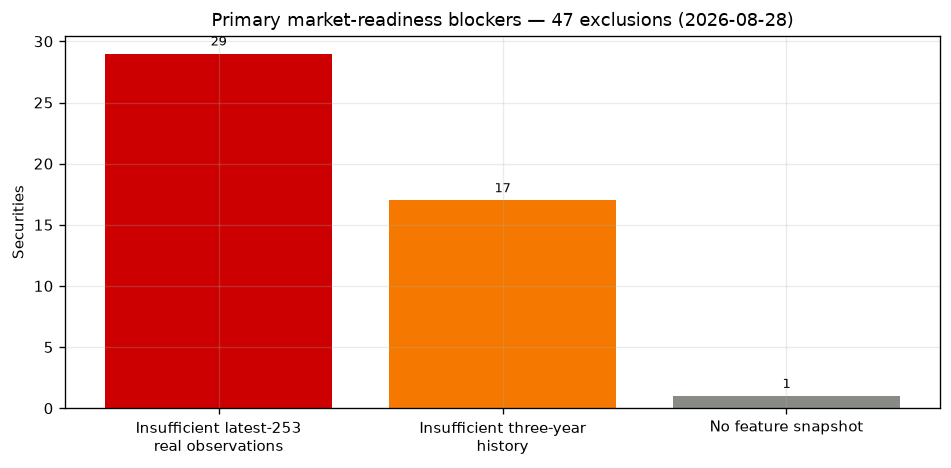

monthly_market_readiness.png


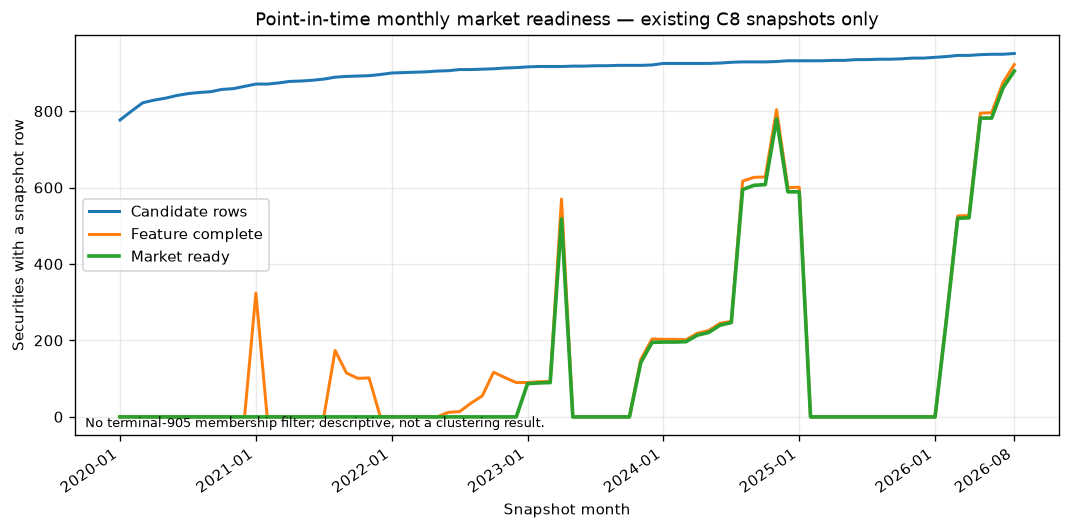

tradability_distribution.png


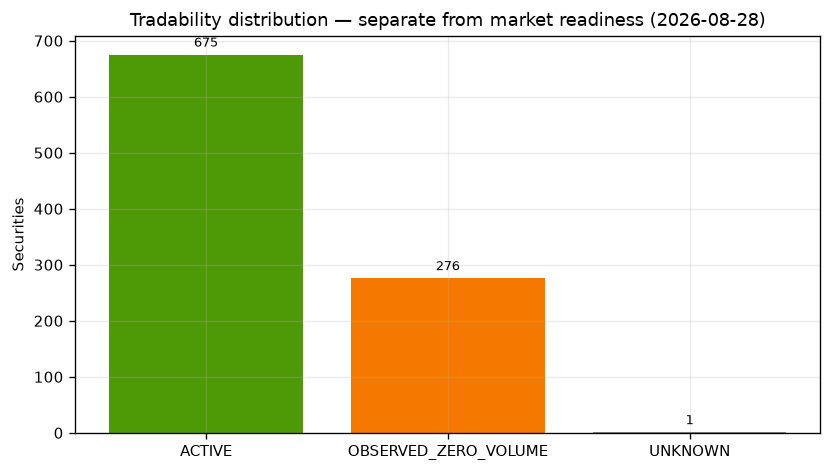

baseline_vs_expansion.png


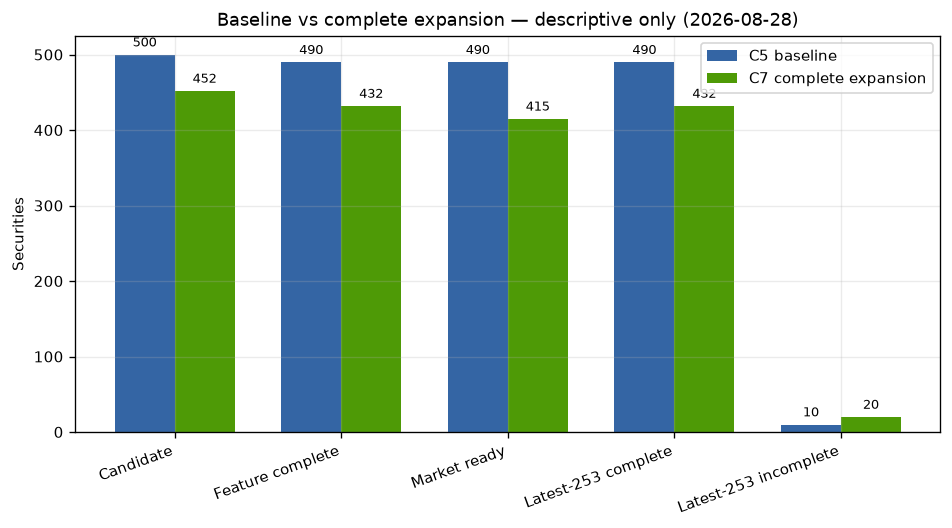

In [16]:
plot_names = [
    "universe_composition.png", "readiness_funnel.png",
    "required_feature_coverage.png", "latest253_status.png",
    "market_readiness_blockers.png", "monthly_market_readiness.png",
    "tradability_distribution.png", "baseline_vs_expansion.png",
]
for name in plot_names:
    print(name)
    display(Image(filename=str(REPORT_DIR / "plots" / name)))


## Per-security inspection

In [17]:
per_security = pd.read_csv(REPORT_DIR / "per_security.csv")
print("Rows:", len(per_security))
display(per_security.head())


Rows: 952


,security_id,ticker,exchange,candidate_source,snapshot_date,feature_snapshot_present,feature_complete,market_feature_ready_v2,latest253_complete,trading_activity_status,...,calendar_uncertain_253,boundary_sessions_253,mom_21_available,mom_63_available,mom_126_available,mom_252_available,vol_63_available,mdd_126_available,beta_126_available,liquidity_21_available
0,KBS:HNX:ADC,ADC,HNX,C5_BASELINE_500,2026-08-28,True,True,True,True,OBSERVED_ZERO_VOLUME,...,0,0,True,True,True,True,True,True,True,True
1,KBS:HNX:ALT,ALT,HNX,C7_COMPLETE_EXPANSION,2026-08-28,True,True,True,True,OBSERVED_ZERO_VOLUME,...,0,0,True,True,True,True,True,True,True,True
2,KBS:HNX:AMC,AMC,HNX,C5_BASELINE_500,2026-08-28,True,True,True,True,OBSERVED_ZERO_VOLUME,...,0,0,True,True,True,True,True,True,True,True
3,KBS:HNX:AME,AME,HNX,C5_BASELINE_500,2026-08-28,True,True,True,True,OBSERVED_ZERO_VOLUME,...,0,0,True,True,True,True,True,True,True,True
4,KBS:HNX:AMV,AMV,HNX,C5_BASELINE_500,2026-08-28,True,True,True,True,ACTIVE,...,0,0,True,True,True,True,True,True,True,True


## Latest-253 incomplete securities

`CALENDAR_UNCERTAIN` is not a provider gap, suspension, delisting or
not-listed claim. Calendar evidence is not official-authoritative.


In [18]:
incomplete = per_security.loc[~per_security["latest253_complete"]]
display(incomplete[[
    "ticker", "exchange", "candidate_source", "calendar_uncertain_253",
    "boundary_sessions_253", "primary_market_blocker",
]].sort_values("ticker"))
print("Incomplete count:", len(incomplete))


,ticker,exchange,candidate_source,calendar_uncertain_253,boundary_sessions_253,primary_market_blocker
250,AAN,HOSE,C7_COMPLETE_EXPANSION,0,182,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS
571,AAV,UPCOM,C5_BASELINE_500,7,0,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS
261,AFX,HOSE,C7_COMPLETE_EXPANSION,6,0,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS
587,ALC,UPCOM,C7_COMPLETE_EXPANSION,0,99,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS
591,ANI,UPCOM,C7_COMPLETE_EXPANSION,0,207,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS
264,ANT,HOSE,C7_COMPLETE_EXPANSION,5,0,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS
636,BQP,UPCOM,C7_COMPLETE_EXPANSION,0,50,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS
645,BT6,UPCOM,C7_COMPLETE_EXPANSION,0,137,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS
683,CLI,UPCOM,C7_COMPLETE_EXPANSION,0,170,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS
301,CRV,HOSE,C7_COMPLETE_EXPANSION,0,32,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS


Incomplete count: 30


## Market-ready securities

In [19]:
market_ready = per_security.loc[per_security["market_feature_ready_v2"]]
print(f"Market ready: {len(market_ready)} / {len(per_security)}")
display(market_ready[[
    "ticker", "exchange", "candidate_source", "trading_activity_status"
]].head(30))


Market ready: 905 / 952


,ticker,exchange,candidate_source,trading_activity_status
0,ADC,HNX,C5_BASELINE_500,OBSERVED_ZERO_VOLUME
1,ALT,HNX,C7_COMPLETE_EXPANSION,OBSERVED_ZERO_VOLUME
2,AMC,HNX,C5_BASELINE_500,OBSERVED_ZERO_VOLUME
3,AME,HNX,C5_BASELINE_500,OBSERVED_ZERO_VOLUME
4,AMV,HNX,C5_BASELINE_500,ACTIVE
5,API,HNX,C7_COMPLETE_EXPANSION,ACTIVE
6,APS,HNX,C5_BASELINE_500,ACTIVE
7,ARM,HNX,C7_COMPLETE_EXPANSION,OBSERVED_ZERO_VOLUME
8,ATS,HNX,C5_BASELINE_500,OBSERVED_ZERO_VOLUME
9,BAB,HNX,C5_BASELINE_500,ACTIVE


## Market-readiness failures

In [20]:
failures = per_security.loc[~per_security["market_feature_ready_v2"]]
display(failures[[
    "ticker", "exchange", "candidate_source", "feature_complete",
    "latest253_complete", "primary_market_blocker", "all_market_blockers",
]].sort_values(["primary_market_blocker", "ticker"]))


,ticker,exchange,candidate_source,feature_complete,latest253_complete,primary_market_blocker,all_market_blockers
250,AAN,HOSE,C7_COMPLETE_EXPANSION,False,False,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,MISSING_REQUIRED_FEATURES|INSUFFICIENT_LATEST2...
571,AAV,UPCOM,C5_BASELINE_500,False,False,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,MISSING_REQUIRED_FEATURES|INSUFFICIENT_LATEST2...
261,AFX,HOSE,C7_COMPLETE_EXPANSION,False,False,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,MISSING_REQUIRED_FEATURES|INSUFFICIENT_LATEST2...
587,ALC,UPCOM,C7_COMPLETE_EXPANSION,False,False,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,MISSING_REQUIRED_FEATURES|INSUFFICIENT_LATEST2...
591,ANI,UPCOM,C7_COMPLETE_EXPANSION,False,False,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,MISSING_REQUIRED_FEATURES|INSUFFICIENT_LATEST2...
264,ANT,HOSE,C7_COMPLETE_EXPANSION,False,False,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,MISSING_REQUIRED_FEATURES|INSUFFICIENT_LATEST2...
636,BQP,UPCOM,C7_COMPLETE_EXPANSION,False,False,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,MISSING_REQUIRED_FEATURES|INSUFFICIENT_LATEST2...
645,BT6,UPCOM,C7_COMPLETE_EXPANSION,False,False,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,MISSING_REQUIRED_FEATURES|INSUFFICIENT_LATEST2...
683,CLI,UPCOM,C7_COMPLETE_EXPANSION,False,False,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,MISSING_REQUIRED_FEATURES|INSUFFICIENT_LATEST2...
301,CRV,HOSE,C7_COMPLETE_EXPANSION,False,False,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,MISSING_REQUIRED_FEATURES|INSUFFICIENT_LATEST2...


## Feature-complete but not market-ready

In [21]:
complete_not_ready = per_security.loc[
    per_security["feature_complete"] & ~per_security["market_feature_ready_v2"]
]
display(complete_not_ready[[
    "ticker", "exchange", "candidate_source", "primary_market_blocker"
]].sort_values("ticker"))


,ticker,exchange,candidate_source,primary_market_blocker
569,AAH,UPCOM,C7_COMPLETE_EXPANSION,INSUFFICIENT_THREE_YEAR_HISTORY
586,AIG,UPCOM,C7_COMPLETE_EXPANSION,INSUFFICIENT_THREE_YEAR_HISTORY
600,AVG,UPCOM,C7_COMPLETE_EXPANSION,INSUFFICIENT_THREE_YEAR_HISTORY
612,BGE,UPCOM,C7_COMPLETE_EXPANSION,INSUFFICIENT_THREE_YEAR_HISTORY
617,BHH,UPCOM,C7_COMPLETE_EXPANSION,INSUFFICIENT_THREE_YEAR_HISTORY
631,BMK,UPCOM,C7_COMPLETE_EXPANSION,INSUFFICIENT_THREE_YEAR_HISTORY
726,DKG,UPCOM,C7_COMPLETE_EXPANSION,INSUFFICIENT_THREE_YEAR_HISTORY
329,DSE,HOSE,C7_COMPLETE_EXPANSION,INSUFFICIENT_THREE_YEAR_HISTORY
767,F88,UPCOM,C7_COMPLETE_EXPANSION,INSUFFICIENT_THREE_YEAR_HISTORY
783,GDA,UPCOM,C7_COMPLETE_EXPANSION,INSUFFICIENT_THREE_YEAR_HISTORY


## Monthly readiness trajectory

Rows are derived from each existing C8 monthly feature snapshot. Earlier months
are **not** filtered by terminal 2026-08-28 membership in the 905-security set.
This is descriptive evidence for PIT-safe M2-PREP window design.


In [22]:
monthly = pd.read_csv(REPORT_DIR / "monthly_market_readiness.csv")
display(monthly)
print("Range:", monthly["snapshot_date"].iloc[0], "→", monthly["snapshot_date"].iloc[-1])


,snapshot_date,candidate_rows,feature_complete,market_feature_ready_v2,baseline_rows,baseline_ready,expansion_rows,expansion_ready
0,2020-01-31,777,0,0,396,0,381,0
1,2020-02-28,800,0,0,419,0,381,0
2,2020-03-31,822,0,0,439,0,383,0
3,2020-04-29,829,0,0,446,0,383,0
4,2020-05-29,834,0,0,450,0,384,0
...,...,...,...,...,...,...,...,...
75,2026-04-29,946,527,521,500,259,446,262
76,2026-05-29,948,795,782,500,424,448,358
77,2026-06-30,949,796,782,500,425,449,357
78,2026-07-31,949,875,861,500,463,449,398


Range: 2020-01-31 → 2026-08-28


## Blocker summary

In [23]:
blockers = pd.read_csv(REPORT_DIR / "blocker_summary.csv")
display(blockers)


,section,blocker,security_count,session_count,semantics
0,market_readiness_primary,INSUFFICIENT_LATEST253_REAL_OBSERVATIONS,29,NaN,primary mutually exclusive cause
1,market_readiness_primary,INSUFFICIENT_THREE_YEAR_HISTORY,17,NaN,primary mutually exclusive cause
2,market_readiness_primary,NO_FEATURE_SNAPSHOT_AT_COMPARISON_DATE,1,NaN,primary mutually exclusive cause
3,latest253_incomplete,CALENDAR_UNCERTAIN,14,227.0,calendar evidence is not official-authoritative
4,latest253_incomplete,IDENTITY_OR_PROVIDER_BOUNDARY,16,2266.0,identity or provider observation boundary; not...


## Historical pipeline continuity

**HISTORICAL PIPELINE REFERENCE ONLY:** the former KBS notebook described
500 selected securities, 614,430 daily rows and 169 latest market-feature-ready
securities. Do not interpret 169 → 905 as a direct improvement percentage:
provider, canonicalization, readiness semantics and universe changed materially.


## Final M1 status

- **M1 MARKET DATA FOUNDATION:** COMPLETE FOR MARKET-ONLY EXPERIMENT PREPARATION
- **Strict research gate:** NOT READY
- **Current proposed latest-snapshot market-only universe:** 905 securities
- **historical_identity_ready:** 0
- **research_ready:** 0
- **Next stage:** M2-PREP — MARKET-ONLY EXPERIMENT PROTOCOL

This notebook authorizes neither backtest nor investment/final-universe claims.
